# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

In [2]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

In [3]:
from sampler.linear_basis import BasisConstructor

In [4]:
gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=4,
                               basis_function='fourier',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)


In [10]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix

noise_wave_X, index_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)

{'unc': (0, 24), 'cos': (24, 48), 'sin': (48, 72), 'rx': (72, 96)}
(4423680, 96)


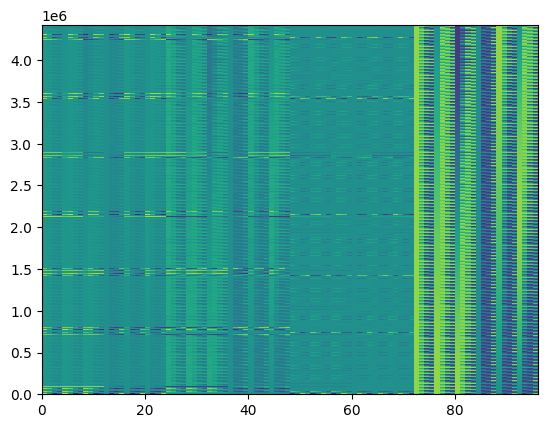

In [11]:
print(index_dict)
print(noise_wave_X.shape)

plt.pcolormesh(noise_wave_X)
plt.show()

In [6]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]

In [15]:
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix

smooth_source_basis = generate_smooth_source_matrix(observation,
                                                    reflections,
                                                    source_basis=ambient_basis,
                                                    source_label=['internal_load',
                                                                  'short',
                                                                  'open',
                                                                  'long_open',
                                                                  'long_short'])

heated_load_source_basis = generate_smooth_source_matrix(observation,
                                                    reflections,
                                                    source_basis=ambient_basis,
                                                    source_label=['heated_load'])

# smooth_antenna_source_basis = generate_smooth_source_matrix(observation,
#                                                     reflections,
#                                                     source_basis=ambient_basis,
#                                                     source_label=['antenna'])


noise_wave_basis,_ = generate_noise_wave_transfer_matrix(observation_data=observation,
                                                       reflection_data=reflections,
                                                       unc_basis=unc_basis,
                                                       cos_basis=cos_basis,
                                                       sin_basis=sin_basis,
                                                       rx_basis=rx_basis)

In [ ]:
antenna_source_basis = generate_non_smooth_source_matrix(observation,
                                                         reflections,
                                                         source_label='antenna')


print(antenna_source_basis.shape)

print(antenna_source_basis.shape[-1] / antenna_source_basis.shape[0])

4423680 1187840
(4423680, 1187840)
0.26851851851851855


: 

In [ ]:

antenna_noise_wave_operator = np.concatenate((antenna_source_basis,
                                              noise_wave_basis),
                                              axis=1)

print(antenna_noise_wave_operator.shape)

In [7]:
print(antenna_source_basis[:,0])

[0. 0. 0. ... 0. 0. 0.]
